In [2]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df

,customer_ID,gender,tenure,internet_service,contract,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,1,DSL,Month-to-month,Electronic check,30,30,0
1,5575-GNVDE,Male,34,DSL,One year,Mailed check,57,1890,0
2,3668-QPYBK,Male,2,DSL,Month-to-month,Mailed check,54,108,1
3,7795-CFOCW,Male,45,DSL,One year,Bank transfer (automatic),42,1841,0
4,9237-HQITU,Female,2,Fiber optic,Month-to-month,Electronic check,71,152,1
...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,24,DSL,One year,Mailed check,85,1991,0
7039,2234-XADUH,Female,72,Fiber optic,One year,Credit card (automatic),103,7363,0
7040,4801-JZAZL,Female,11,DSL,Month-to-month,Electronic check,30,346,0
7041,8361-LTMKD,Male,4,Fiber optic,Month-to-month,Mailed check,74,307,1


In [ ]:
# Data understanding

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_ID       7043 non-null   str  
 1   gender            7043 non-null   str  
 2   tenure            7043 non-null   int64
 3   internet_service  7043 non-null   str  
 4   contract          7043 non-null   str  
 5   payment_method    7043 non-null   str  
 6   monthly_charges   7043 non-null   int64
 7   total_charges     7043 non-null   str  
 8   churn             7043 non-null   int64
dtypes: int64(3), str(6)
memory usage: 495.3 KB


In [9]:
df.describe()

,tenure,monthly_charges,churn
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.783047,0.265370
std,24.559481,30.094301,0.441561
min,0.000000,18.000000,0.000000
25%,9.000000,36.000000,0.000000
50%,29.000000,70.000000,0.000000
75%,55.000000,90.000000,1.000000
max,72.000000,119.000000,1.000000


In [5]:
df.shape

(7043, 9)

In [ ]:
# Check missing values

In [6]:
df.isnull().sum()

customer_ID         0
gender              0
tenure              0
internet_service    0
contract            0
payment_method      0
monthly_charges     0
total_charges       0
churn               0
dtype: int64

In [ ]:
# Check duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Handling null values

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,customer_ID,gender,tenure,internet_service,contract,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,1,DSL,Month-to-month,Electronic check,30,30,0
1,5575-GNVDE,Male,34,DSL,One year,Mailed check,57,1890,0
2,3668-QPYBK,Male,2,DSL,Month-to-month,Mailed check,54,108,1
3,7795-CFOCW,Male,45,DSL,One year,Bank transfer (automatic),42,1841,0
4,9237-HQITU,Female,2,Fiber optic,Month-to-month,Electronic check,71,152,1
...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,24,DSL,One year,Mailed check,85,1991,0
7039,2234-XADUH,Female,72,Fiber optic,One year,Credit card (automatic),103,7363,0
7040,4801-JZAZL,Female,11,DSL,Month-to-month,Electronic check,30,346,0
7041,8361-LTMKD,Male,4,Fiber optic,Month-to-month,Mailed check,74,307,1


In [ ]:
# Handling duplicate values

In [5]:
df.drop_duplicates(inplace=True)

In [ ]:
# Exploratory Data Analysis (EDA)

In [ ]:
# Churn Distribution

In [6]:
df['churn'].value_counts()*(1/100)

churn
0    51.74
1    18.69
Name: count, dtype: float64

In [ ]:
# Unique values

In [11]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [12]:
df['internet_service'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [13]:
df['payment_method'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [14]:
df['churn'].unique()

array([0, 1])

In [ ]:
# Convert categorical data / Mapping

In [7]:
df['gender'] = df['gender'].map({'Male' : 1, 'Female' : 2})

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_ID       7043 non-null   str  
 1   gender            7043 non-null   int64
 2   tenure            7043 non-null   int64
 3   internet_service  7043 non-null   str  
 4   contract          7043 non-null   str  
 5   payment_method    7043 non-null   str  
 6   monthly_charges   7043 non-null   int64
 7   total_charges     7043 non-null   str  
 8   churn             7043 non-null   int64
dtypes: int64(4), str(5)
memory usage: 495.3 KB


In [7]:
df

,customer_ID,gender,tenure,internet_service,contract,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,2,1,DSL,Month-to-month,Electronic check,30,30,0
1,5575-GNVDE,1,34,DSL,One year,Mailed check,57,1890,0
2,3668-QPYBK,1,2,DSL,Month-to-month,Mailed check,54,108,1
3,7795-CFOCW,1,45,DSL,One year,Bank transfer (automatic),42,1841,0
4,9237-HQITU,2,2,Fiber optic,Month-to-month,Electronic check,71,152,1
...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,24,DSL,One year,Mailed check,85,1991,0
7039,2234-XADUH,2,72,Fiber optic,One year,Credit card (automatic),103,7363,0
7040,4801-JZAZL,2,11,DSL,Month-to-month,Electronic check,30,346,0
7041,8361-LTMKD,1,4,Fiber optic,Month-to-month,Mailed check,74,307,1


In [ ]:
# Churn by Contract

In [8]:
(df.groupby('contract')['churn'].mean()*100).round(2)

contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn, dtype: float64

In [ ]:
# Alternative way

In [9]:
df.groupby('contract')['churn'].agg(['count','mean']).assign(
    churn_pct = lambda x: (x['mean'] * 100).round(2)
)

,count,mean,churn_pct
contract,,,
Month-to-month,3875,0.427097,42.71
One year,1473,0.112695,11.27
Two year,1695,0.028319,2.83


In [ ]:
# Churn by Payment Method

In [34]:
(df.groupby('payment_method')['churn'].mean()*100).round(2)

payment_method
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: churn, dtype: float64

In [ ]:
# Churn by Gender

In [35]:
(df.groupby('gender')['churn'].mean()*100).round(2)

gender
1    26.16
2    26.92
Name: churn, dtype: float64

In [ ]:
# Churn vs Tenure

In [10]:
(df.groupby('tenure')['churn'].mean()*100).round(2)

tenure
0      0.00
1     61.99
2     51.68
3     47.00
4     47.16
      ...  
68     9.00
69     8.42
70     9.24
71     3.53
72     1.66
Name: churn, Length: 73, dtype: float64

In [ ]:
# Tenure groups vs churn

In [8]:
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1 Year','1-2 Years','2-4 Years','4-6 Years'])

(df.groupby('tenure_group')['churn'].mean() * 100).round(2)

tenure_group
0-1 Year     47.68
1-2 Years    28.71
2-4 Years    20.39
4-6 Years     9.51
Name: churn, dtype: float64

In [ ]:
# Churn vs Charges

In [9]:
(df.groupby('monthly_charges')['churn'].mean()*100).round(2)

monthly_charges
18      0.00
19      9.22
20      8.64
21      8.47
23     28.57
       ...  
115     3.70
116     9.68
117     8.33
118    40.00
119     0.00
Name: churn, Length: 101, dtype: float64

In [ ]:
# Charge group

In [10]:
df['charge_group'] = pd.cut(df['monthly_charges'],
                           bins=[0,50,100,150],
                           labels=['Low','Medium','High'])

In [11]:
df

,customer_ID,gender,tenure,internet_service,contract,payment_method,monthly_charges,total_charges,churn,tenure_group,charge_group
0,7590-VHVEG,2,1,DSL,Month-to-month,Electronic check,30,30,0,0-1 Year,Low
1,5575-GNVDE,1,34,DSL,One year,Mailed check,57,1890,0,2-4 Years,Medium
2,3668-QPYBK,1,2,DSL,Month-to-month,Mailed check,54,108,1,0-1 Year,Medium
3,7795-CFOCW,1,45,DSL,One year,Bank transfer (automatic),42,1841,0,2-4 Years,Low
4,9237-HQITU,2,2,Fiber optic,Month-to-month,Electronic check,71,152,1,0-1 Year,Medium
...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,24,DSL,One year,Mailed check,85,1991,0,1-2 Years,Medium
7039,2234-XADUH,2,72,Fiber optic,One year,Credit card (automatic),103,7363,0,4-6 Years,High
7040,4801-JZAZL,2,11,DSL,Month-to-month,Electronic check,30,346,0,0-1 Year,Low
7041,8361-LTMKD,1,4,Fiber optic,Month-to-month,Mailed check,74,307,1,0-1 Year,Medium


In [ ]:
# Churn vs charge groups

In [15]:
(df.groupby('charge_group')['churn'].mean() * 100).round(2)

charge_group
Low       15.97
Medium    32.84
High      27.34
Name: churn, dtype: float64

In [ ]:
# Visualization

In [ ]:
# Contract vs Churn

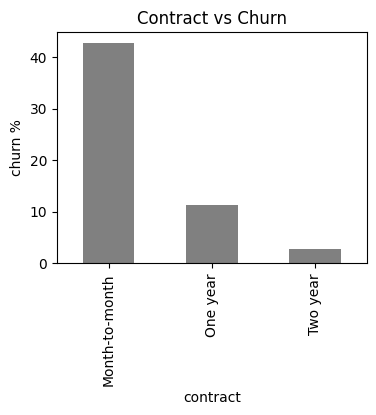

In [24]:
plt.figure(figsize = (4, 3))
(df.groupby('contract')['churn'].mean()*100).plot(kind = 'bar', color = 'grey')
plt.title('Contract vs Churn')
plt.ylabel('churn %')
plt.show()

In [ ]:
# Tenure vs Churn

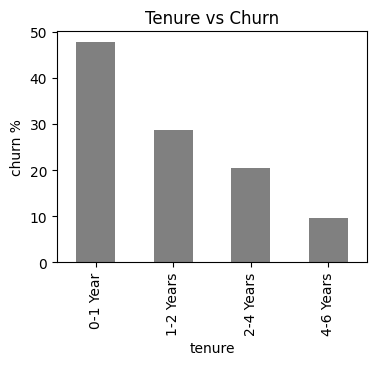

In [28]:
plt.figure(figsize = (4, 3))
(df.groupby('tenure_group')['churn'].mean()*100).plot(kind = 'bar', color = 'grey')
plt.title('Tenure vs Churn')
plt.xlabel('tenure')
plt.ylabel('churn %')
plt.show()

In [ ]:
# Churn vs Charges

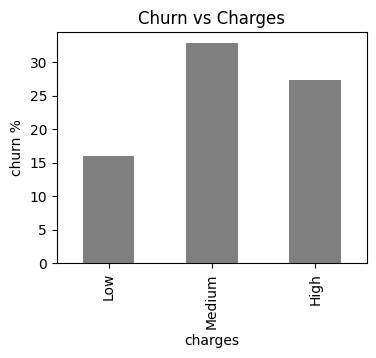

In [31]:
plt.figure(figsize = (4, 3))
(df.groupby('charge_group')['churn'].mean()*100).plot(kind = 'bar', color = 'grey')
plt.title('Churn vs Charges')
plt.xlabel('charges')
plt.ylabel('churn %')
plt.show()

In [ ]:
# Churn by Gender

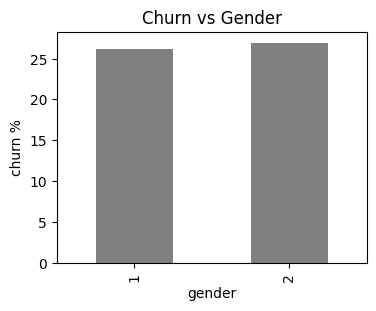

In [32]:
plt.figure(figsize = (4, 3))
(df.groupby('gender')['churn'].mean()*100).plot(kind = 'bar', color = 'grey')
plt.title('Churn vs Gender')
plt.xlabel('gender')
plt.ylabel('churn %')
plt.show()

In [ ]:
# Churn by Payment Method

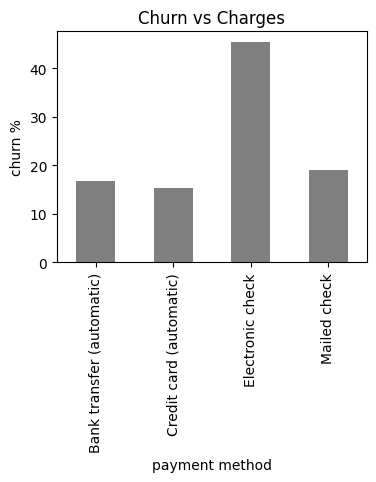

In [33]:
plt.figure(figsize = (4, 3))
(df.groupby('payment_method')['churn'].mean()*100).plot(kind = 'bar', color = 'grey')
plt.title('Churn vs Charges')
plt.xlabel('payment method')
plt.ylabel('churn %')
plt.show()

In [ ]:
# Build Prediction Model

In [ ]:
# Import important libraries

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Select features

In [41]:
X = df[['tenure', 'monthly_charges']]
y = df['churn']

In [ ]:
# Split Data

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Build model

In [43]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Evaluate model

In [44]:
print(model.score(X_test, y_test))

0.7750177430801988


In [ ]:
# Prediction 

In [ ]:
# array([1]) = Customer will churn (leave)

In [ ]:
# array([0]) = Customer will NOT churn (stay)

In [66]:
new_data = pd.DataFrame([[1, 56]], columns=['tenure', 'monthly_charges'])

model.predict(new_data)

array([0])

In [ ]:
## Key Insights

In [ ]:
# Customers with low tenure are more likely to churn
# High monthly charges increase churn risk
# Month-to-month contracts show higher churn

In [ ]:
# Save updated file seperately

In [12]:
df.to_csv("Telco-Customer-Churn-updated.csv", index=False)